In [6]:
import os

# Print the current working directory
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\User\AppData\Local\Programs\Microsoft VS Code


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.decomposition import PCA
import models


# Fonction pour projeter les échantillons sur les vecteurs
def proj_for(x_values, u, sample):
    sample_proj = sample.dot(u)
    
    if x_values is None:
        x_values = sample

    x_proj = x_values.dot(u)
    sample_sorted = np.sort(sample_proj)
    n = len(sample)
    
    cdf_values = np.searchsorted(sample_sorted, x_proj, side='right') / n
    return x_proj, cdf_values

# Fonction pour calculer les PIT
def calculate_pit(values, u, sample):
    return proj_for(values, u, sample)[1]

#Fonction pour afficher les graphiques PIT
def plot_pit(pit_values, dimension, pca, n_samples, name):
    cols = 3  # Fixe 3 graphes par ligne
    rows = int(np.ceil(dimension / cols))  # Nombre de lignes nécessaires

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))  # Ajustement dynamique de la taille

    # S'assurer que `axs` est toujours un tableau 2D pour éviter les erreurs
    axs = np.array(axs).reshape(rows, cols)

    for i in range(dimension):
        row, col = divmod(i, cols)  # Trouver la position dans la grille
        ax = axs[row, col]  # Récupérer l'axe correspondant
        
        ax.hist(pit_values[i], bins=10, density=True, alpha=0.6, color='g')
        title = f"PIT - Direction selon la composante ${i+1}$" if pca else f"PIT - Direction selon $e_{i+1}$"
        ax.set_title(title)
        ax.set_xlabel("Valeur projetée du PIT")
        ax.set_ylabel("Densité")

    # Supprimer les sous-graphiques vides si `dimension` n'est pas un multiple de 3
    for i in range(dimension, rows * cols):
        fig.delaxes(axs.flatten()[i])

    plt.tight_layout()  # Ajuster automatiquement l'affichage
    filename = f"PIT_proj_PCA_{n_samples}_{name}.png" if pca else f"PIT_proj_{n_samples}_{name}.png"
    plt.savefig(filename)
    plt.show()


def create_exp_correlation_matrix(d, diagonal_value=1.0, off_diagonal_value=np.exp(-1)):
    return np.array([[diagonal_value if i == j else off_diagonal_value for j in range(d)] for i in range(d)])

def create_mean_vector(d, value=0):
    return np.full(d, value)

In [ ]:
# Flags et paramètres
pca_flag = 1
normal_flag = 1
d = 3
n_samples = 5000

mean = create_mean_vector(d)
mean_hat = create_mean_vector(d, value=0.5)
covariance = create_exp_correlation_matrix(d)
covariance_hat = create_exp_correlation_matrix(d)

model = GaussianModel(mean, covariance, n_samples)
'''lower_bounds = np.array([0, 1, -2])  # Bornes inférieures pour chaque composante
upper_bounds = np.array([1, 3, 2])   # Bornes supérieures pour chaque composante

# Créer un modèle uniforme
model = UniformModel(n_samples, lower_bounds, upper_bounds)'''
Y = model.generate_samples()

# Choisir le modèle et générer les échantillons
if normal_flag:
    model_hat = GaussianModel(mean_hat, covariance_hat, n_samples)
    Y_hat = model_hat.generate_samples()
    name = "RANK_Normal_var_overestimated"
else:
    model_hat = NormalModel(n_samples)
    Y_hat = model_hat.generate_samples()
    name = "Non-normal"


In [4]:
# PCA ou identité
if pca_flag:
    pca = PCA(n_components=d)
    pca.fit(Y_hat)
    vectors = pca.components_
else:
    vectors = np.eye(d)


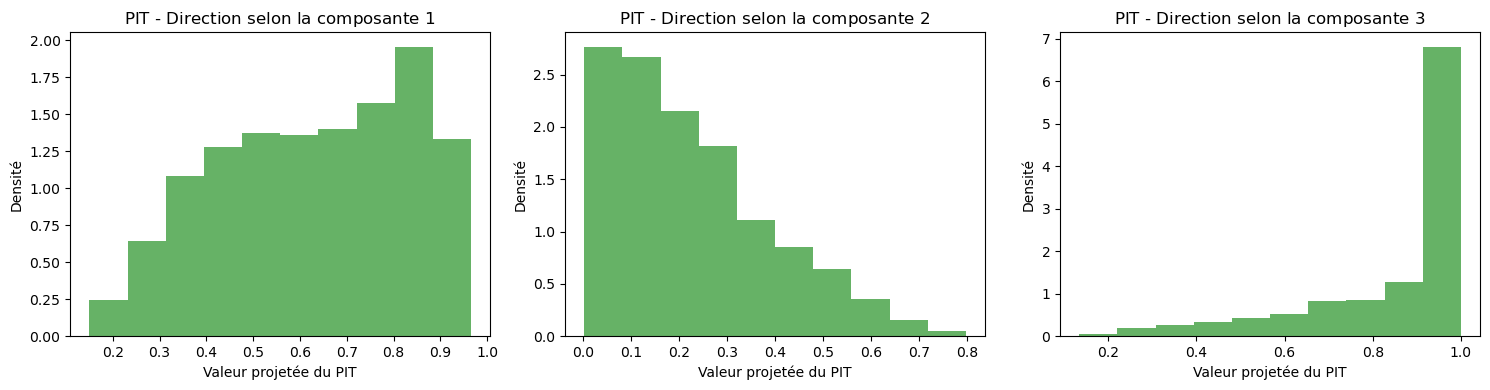

In [5]:
# Calcul des PIT
pit_values = [calculate_pit(Y, vectors[i], Y_hat) for i in range(d)]

# Tracé des PIT
plot_pit(pit_values, d, pca_flag, n_samples, name)